### 1. Obtención y comprensión inicial de los datos

El dataset **Ames Housing** 🏡 contiene información detallada sobre propiedades residenciales vendidas en Ames, Iowa (Estados Unidos). Incluye variables relacionadas con las características de las viviendas, como superficie, calidad de construcción, antigüedad, cantidad de habitaciones y otras características estructurales, además del precio de venta de cada propiedad.

#### Preguntas a responder

- ¿Cómo se obtiene y carga el dataset?
- ¿Cuál es la estructura general del conjunto de datos?
- ¿Qué variables contiene y qué representa cada una?
- ¿Existen valores faltantes, registros duplicados o inconsistencias?
- ¿Qué características presentan las variables antes del análisis?

#### Objetivos

- Importar las librerías necesarias.
- Definir las rutas de trabajo.
- Cargar el dataset.
- Realizar una inspección inicial del conjunto de datos:
  - Visualizar las primeras y últimas observaciones.
  - Conocer las dimensiones del dataset.
  - Revisar la información general (`info()`).
  - Analizar los tipos de datos.
  - Consultar el diccionario de variables.
  - Identificar valores faltantes.
  - Detectar registros duplicados.
  - Obtener estadísticas descriptivas de las variables.

In [3]:
# Librerias 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from pathlib import Path
import os
print ("librerias ok")

librerias ok


In [4]:
# Directorio actual
print(os.getcwd())

d:\Josefina\Proyectos\Datascience\Curso_ML\Modelos_ML\housing-price-analysis


In [9]:
# Ruta del proyecto
ruta_proyecto = Path.cwd().parent
print(ruta_proyecto)
#Ruta donde se encuentra el dataset
ruta_raw = ruta_proyecto  /  "data" 

print(ruta_raw)

#Dataset a utilizar descargado previamente de kaggle 
# https://www.kaggle.com/datasets/marcopale/housing?resource=download
archivo = ruta_raw / "AmesHousing.csv"
housing = pd.read_csv(archivo)


d:\Josefina\Proyectos\Datascience\Curso_ML\Modelos_ML
d:\Josefina\Proyectos\Datascience\Curso_ML\Modelos_ML\data


In [ ]:
# # Otra format
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("marcopale/housing")

# print("Path to dataset files:", path)

##### Objetivo del proyecto

El dataset de viviendas de Ames permite abordar una amplia variedad de preguntas relacionadas con el mercado inmobiliario. En este proyecto se utilizará un mismo conjunto de datos para estudiar distintos problemas de aprendizaje supervisado, tanto de regresión como de clasificación.

La pregunta principal que guiará el análisis será:

- ¿Qué características de una vivienda explican y permiten predecir su precio de venta?

A partir de esta pregunta general, cada modelo abordará un objetivo específico.

- Problemas de regresión: el objetivo es modelar el precio de venta (SalePrice) como una variable continua.

Algunas preguntas que se intentarán responder son:

- Regresión lineal simple: ¿En qué medida una única característica, por ejemplo el área habitable (GrLivArea), explica el precio de venta?
- Regresión lineal múltiple: ¿Qué combinación de variables permite explicar y predecir mejor el precio de una vivienda?
- KNN Regressor, Árboles de regresión y Random Forest Regressor: ¿Mejoran la capacidad predictiva respecto a los modelos lineales al capturar relaciones no lineales entre las variables?
Problemas de clasificación

Además del problema de regresión, se construirá una variable binaria denominada HighPrice, que clasificará las viviendas en dos grupos (precio alto o precio bajo) utilizando como umbral la mediana del precio de venta.

- La pregunta en este caso será: Es posible clasificar una vivienda como de precio alto o bajo a partir de sus características?

Para responderla se implementarán modelos como:

Regresión logística.
KNN Classifier.
Árboles de decisión para clasificación.
Random Forest Classifier.

In [10]:
#Visualizamos las primeras filas
housing.head()
# Vemos que hay muchas variables que capaz no son de interes, hay que revisarlas con mayor profunidad

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
# Verificamos dimensiones
housing.shape


(2930, 82)

Tiene 82 variables (columnas), es un dataset muy grande, hay que evaluar muy bien que variables vamos a considerar.

Se agrego un dataset en la carpeta info que nos muestra que significa cada una y de esta forma podemos entender mejor cual tomar.

In [ ]:
#Tipos de los datos
housing.dtypes

#Cuantos son string?, int64, booleanos?
#Hay otros?

housing.dtypes.value_counts()

str        43
int64      28
float64    11
Name: count, dtype: int64

In [12]:
#Info general
housing.info()


<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

                Nulos  Porcentaje (%)
Lot Frontage      490           16.72
Alley            2732           93.24
Mas Vnr Type     1775           60.58
Mas Vnr Area       23            0.78
Bsmt Qual          80            2.73
Bsmt Cond          80            2.73
Bsmt Exposure      83            2.83
BsmtFin Type 1     80            2.73
BsmtFin SF 1        1            0.03
BsmtFin Type 2     81            2.76
BsmtFin SF 2        1            0.03
Bsmt Unf SF         1            0.03
Total Bsmt SF       1            0.03
Electrical          1            0.03
Bsmt Full Bath      2            0.07
Bsmt Half Bath      2            0.07
Fireplace Qu     1422           48.53
Garage Type       157            5.36
Garage Yr Blt     159            5.43
Garage Finish     159            5.43
Garage Cars         1            0.03
Garage Area         1            0.03
Garage Qual       159            5.43
Garage Cond       159            5.43
Pool QC          2917           99.56
Fence       

C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_11712\3257429429.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=nulos.index, x=nulos.values, palette="pastel")


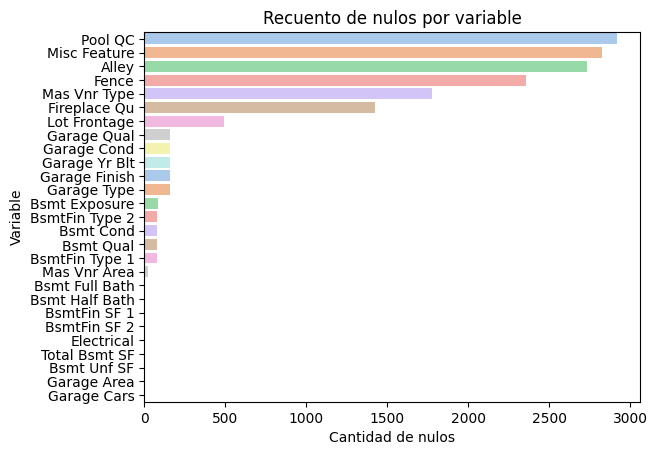

In [18]:

#Cuales son las variables que tienen nulos?
nulos = housing.isnull().sum()

# Mostrar solo las variables que tienen al menos un nulo
#Me quedo solo con las columnas que tienen valores nulos
nulos = nulos[nulos > 0].sort_values(ascending=False)
# print(nulos)



# Cantidad y porcentaje de valores nulos
resumen_nulos = pd.DataFrame({
    "Nulos": housing.isnull().sum(),
    "Porcentaje (%)": (housing.isnull().mean() * 100).round(2)
})

# Mostrar solo las variables con nulos
resumen_nulos = resumen_nulos[resumen_nulos["Nulos"] > 0]
resumen_nulos.sort_values("Porcentaje (%)", ascending=False)
print(resumen_nulos)


#Si lo hacemos en porcentajes del total
porcentaje_nulos = round((housing.isnull().sum() / len(housing)) * 100, 1)
# print(porcentaje_nulos)



#Los visualizamos
plt.Figure(figsize=(5, 4))
# plt.barh(valores_nulos.index, valores_nulos.values)
sns.barplot(y=nulos.index, x=nulos.values, palette="pastel")
plt.title( "Recuento de nulos por variable")
plt.xlabel("Cantidad de nulos")
plt.ylabel("Variable")
plt.show()



In [ ]:
#Hay valores duplicados en el dataset?
housing.duplicated().sum()
# No, no hay!

#Por las dudas verificamos que no hay ID tampoco duplicados
housing["PID"].duplicated().sum()

np.int64(0)

In [ ]:
#Primer estadistico descriptivo de todas las variables
housing.describe()

#Solo vemos algunas que son las numericas. Pero hay algunas que mucho no sirven como:
# Order, PID, Year, y otros. Pero esto forma parte de la seleccion de las variables
# que vamos a hacer despues.

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [ ]:
# Explorar la distribucion de las variables
print(housing.select_dtypes(include="number").shape) # 39 variables
print(housing.select_dtypes(include="object").shape) # 43 variables

(2930, 39)
(2930, 43)


C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_22128\1830577325.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(housing.select_dtypes(include="object").shape)


Resumen de la notebook
- El dataset contiene 2930 observaciones y 82 variables.
- No se detectaron registros duplicados.
- El identificador PID es único para cada propiedad.
- Se identificaron variables con valores faltantes, principalmente relacionadas con características opcionales de las viviendas (por ejemplo, piscina, cercos o chimeneas), las cuales deberán analizarse en la etapa de limpieza.
- El conjunto de datos incluye variables numéricas y categóricas, por lo que será necesario aplicar diferentes estrategias de preprocesamiento antes del modelado.